In [19]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from mxlpy import Model, Simulator, make_protocol
import sys
import os

sys.path.append(os.path.abspath('..'))

from model import Davis2017


In [13]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

In [109]:
# Case 1
m = (
    Davis2017()
     .update_variables({
         'Dpsi': 0.0473751889367654, 
         'pH_lumen': 7.010413517720576,
         })
     )

m.update_parameters({
    'k_KEA3': 0,
    'P_K':0,
    'pmf_init':0,
    'Vmax_ATPsynth':20,
    'n': 14/3,
})

s = Simulator(m)

protocol = make_protocol([
    (60, {'PPFD': 0}),
    (300, {'PPFD': 300}),
    (600, {'PPFD': 0}),
])
vars_davis, fluxes_davis = s.simulate_protocol(protocol, time_points_per_step=10000).get_result().unwrap_or_err()


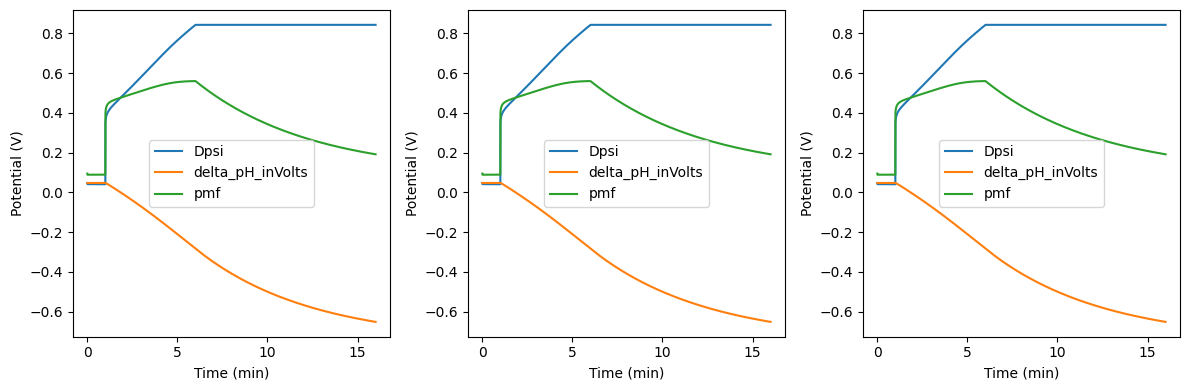

In [110]:
pmf_name = ['Dpsi', "delta_pH_inVolts", 'pmf', ]

fig, axs = plt.subplots(ncols=3, nrows=1, figsize= (12, 4))

for ax, df in zip(axs.flatten(), [vars_davis, vars_davis, vars_davis]):
    for k in pmf_name:
        ax.plot(df.index/60,df[k],  label = k)
    ax.set_ylabel('Potential (V)')
    ax.set_xlabel('Time (min)')
    ax.legend()
    # ax.set_ylim(-0.05, 0.3)
    # ax.axvspan(1,6, color='red', alpha = 0.1)
    # ax.hlines(0,0, 16, color='black', alpha = 0.4)

plt.tight_layout()

In [78]:
def generate_square_wave_based_light_sequence (baseline_duration, baseline_intensity, pulse_duration, pulse_intensity, 
                                        recovery_duration, recovery_intensity, rise_time, time_units, point_frequency,
                                        repeat_cycles):
    pulse_times=[] #array that contains the complete time sequence
    pulse_light=[] #array to contain the complete intensity sequence 
    if time_units=='seconds':
        time_div=1
    elif time_units=='minutes':
        time_div=60
    elif time_units=='hours':
        time_div=60*60

    baseline_duration=baseline_duration*time_div
    baseline_points=baseline_duration*point_frequency #calculate the number of points in the baseline
    baseline_time=np.linspace(0.0, int(baseline_duration), int(baseline_points)) #generate the baseline array, starting at zero
    baseline_intensity_array= np.linspace(int(baseline_intensity), int(baseline_intensity),int(baseline_points)) #fill baseline array with baseline light intensity

    pulse_times=np.append(pulse_times, baseline_time) 
    pulse_light=np.append(pulse_light, baseline_intensity_array)

    riser_duration=rise_time*time_div
    riser_points=riser_duration*point_frequency
    riser_start_time = (baseline_points+1) / point_frequency
    
    riser_end_time = riser_start_time + riser_duration
    riser_time=np.linspace(int(riser_start_time), int(riser_end_time), int(riser_points))
    riser_light=np.linspace(int(baseline_intensity), int(pulse_intensity), int(riser_points))
    #print('rst= ' + str(riser_start_time))
    #print('ret= ' + str(riser_end_time))
    
    pulse_times=np.append(pulse_times, riser_time)
    pulse_light=np.append(pulse_light, riser_light)
    
    pulse_duration=pulse_duration*time_div
    pulse_points=pulse_duration*point_frequency
    #pulse_start_time = (baseline_points + riser_points +1)/point_frequency
    
    pulse_start_time = pulse_times[-1] + 1/point_frequency
    
    pulse_end_time = pulse_start_time + pulse_duration
    
    #print('pst= ' + str(pulse_start_time))
    #print('pet= ' + str(pulse_end_time))


    pulse_time=np.linspace(int(pulse_start_time), int(pulse_end_time), int(pulse_points))
    pulse_light_array=np.linspace(int(pulse_intensity), int(pulse_intensity), int(pulse_points))
    pulse_times=np.append(pulse_times, pulse_time)
    pulse_light=np.append(pulse_light, pulse_light_array)
    
    falling_duration=rise_time*time_div
    falling_points=riser_duration*point_frequency
    
    #falling_start_time = (baseline_points + riser_points + pulse_points + 1) / point_frequency
    falling_start_time = pulse_times[-1] + 1/point_frequency

    falling_end_time = falling_start_time + falling_duration
    
    #print('fst= ' + str(falling_start_time))
    #print('fet= ' + str(falling_end_time))


    falling_time=np.linspace(int(falling_start_time), int(falling_end_time), int(falling_points))
    falling_light=np.linspace(int(pulse_intensity), int(recovery_intensity), int(falling_points))
    
    pulse_times=np.append(pulse_times, falling_time)
    pulse_light=np.append(pulse_light, falling_light)
    
    recovery_duration=recovery_duration*time_div
    recovery_points=recovery_duration*point_frequency
    recovery_start_time = pulse_times[-1] + 1/point_frequency
    recovery_end_time = recovery_start_time + recovery_duration
    

    recovery_time=np.linspace(int(recovery_start_time), int(recovery_end_time), int(recovery_points))
    recovery_light=np.linspace(int(recovery_intensity), int(recovery_intensity), int(recovery_points))

    pulse_times=np.append(pulse_times, recovery_time)
    pulse_light=np.append(pulse_light, recovery_light)
    pulse_times_seq=[]
    pulse_light_seq=[]
    
    for index in range(0,repeat_cycles):
        pulse_times_seq=np.append(pulse_times_seq, pulse_times + index * pulse_times[-1])
        pulse_light_seq=np.append(pulse_light_seq, pulse_light)
    return([pulse_times_seq, pulse_light_seq])


def make_waves():
    # Generate a library of light patterns to use in the simulations.
    light_pattern={}
    
    #a single turnover flash  
    
    baseline_duration=1 # 10 ms dark timein seconds
    baseline_intensity=0 #dark baseline
    pulse_duration=0.001 # 10 ms pulse of bright light 
    pulse_intensity=3000 #pulse is 1000 units
    recovery_duration = 10 #10 s recovery in dark
    recovery_intensity=0 #recovery is dark
    rise_time=.001 #100 ms for the light to rise
    time_units='seconds' 
    point_frequency=1000 #start with a frequency of 1000 points per subtrace
    repeat_cycles=1 #do this once
    wave=generate_square_wave_based_light_sequence (baseline_duration, baseline_intensity,
                        pulse_duration, pulse_intensity, recovery_duration, recovery_intensity, 
                        rise_time, time_units, point_frequency, repeat_cycles)
    light_pattern['single_turnover_flash']=wave
    
    
    #a single, 5-min square wave with peak intensity of 300 uE
    baseline_duration=150 #in seconds
    baseline_intensity=0 #dark baseline
    pulse_duration=300 #300 seconds pulse
    pulse_intensity=300 #pulse is 1000 units
    recovery_duration = 600 #100 seconds recovery
    recovery_intensity=0 #recovery is dark
    rise_time=1 #100 ms for the light to rise
    time_units='seconds' 
    point_frequency=100 #start with a frequency of 1000 points per subtrace
    repeat_cycles=1 #do this once
    wave=generate_square_wave_based_light_sequence (baseline_duration, baseline_intensity,
                        pulse_duration, pulse_intensity, recovery_duration, recovery_intensity, 
                        rise_time, time_units, point_frequency, repeat_cycles)
    
    light_pattern['single_square_5_min_300_max']=wave

    return(light_pattern)

In [79]:
light_pattern = make_waves()

In [84]:
light_pattern['single_square_5_min_300_max'][0]

array([0.00000000e+00, 1.00006667e-02, 2.00013334e-02, ..., 1.05198000e+03, 1.05199000e+03, 1.05200000e+03], shape=(105200,))

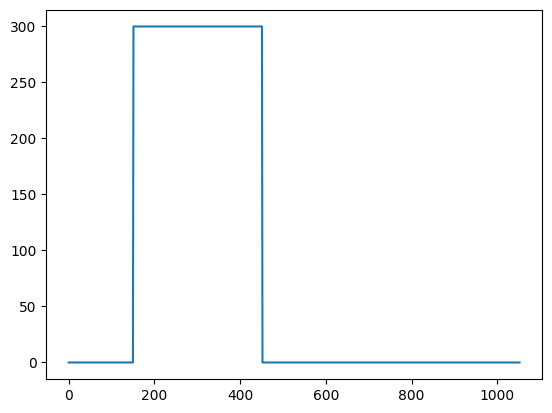

In [85]:
plt.plot(light_pattern['single_square_5_min_300_max'][0], light_pattern['single_square_5_min_300_max'][1])